패키지 설치

In [1]:
!pip install monai==1.3.1 transformers==4.41.0 numpy==1.26.4 nibabel==5.2.1 \
    SimpleITK==2.3.1 einops==0.8.0 peft==0.8.2 safetensors==0.4.3 \
    accelerate deep-translator sentencepiece gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 5

레포지토리 클론 및 데이터셋 다운로드

In [1]:
!git clone https://github.com/yuji4/MedSeg3D-KO.git
!git clone https://github.com/BAAI-DCAI/M3D.git

Cloning into 'MedSeg3D-KO'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 154 (delta 59), reused 134 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (154/154), 29.38 MiB | 11.51 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Cloning into 'M3D'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 305 (delta 90), reused 77 (delta 77), pack-reused 178 (from 1)
Receiving objects: 100% (305/305), 37.16 MiB | 19.06 MiB/s, done.
Resolving deltas: 100% (121/121), done.


In [ ]:
!gdown "1YZQFSonulXuagMIfbJkZeTFJ6qEUuUxL" -O /content/Task07_Pancreas.tar

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1YZQFSonulXuagMIfbJkZeTFJ6qEUuUxL

but Gdown can't. Please check connections and permissions.


라이브러리 임포트

In [7]:
import sys, os
import numpy as np
import nibabel as nib
import torch
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive

sys.path.insert(0, '/content/MedSeg3D-KO')
drive.mount('/content/drive')
print("완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
완료


GPU 확인

In [8]:
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


M3D 모델 로드

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "GoodBaiBai88/M3D-LaMed-Phi-3-4B"

tokenizer = AutoTokenizer.from_pretrained(
    model_name, model_max_length=512, padding_side="right",
    use_fast=False, trust_remote_code=True
)
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.bfloat16,
    device_map='auto', trust_remote_code=True
)
model.eval()
print("모델 로드 성공")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.blocks.patchembedding PatchEmbeddingBlock.__init__:pos_embed: Argument `pos_embed` has been deprecated since version 1.2. It will be removed in version 1.4. please use `proj_type` instead.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.vit ViT.__init__:pos_embed: Argument `pos_embed` has been deprecated since version 1.2. It will be removed in version 1.4. please use `proj_type` instead.
  warn_deprecated(argname, msg, warning_category)


build_sam_vit_3d...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

모델 로드 성공


파이프라인 및 유틸 초기화

In [10]:
from src.inference.segmentation import SegmentationPipeline, _build_english_prompt
from src.inference.model_loader import PROJ_OUT_NUM
from deep_translator import GoogleTranslator
from src.translation.medical_terms import TERM_KO

pipeline = SegmentationPipeline()
pipeline.model = model
pipeline.tokenizer = tokenizer
pipeline._device = next(model.parameters()).device

def dice_score(pred, gt):
    """Dice Similarity Coefficient 계산"""
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = (pred & gt).sum()
    if pred.sum() + gt.sum() == 0:
        return 1.0
    return 2 * intersection / (pred.sum() + gt.sum())

def run_inference(image_pt, prompt, threshold=0.5):
    """프롬프트로 추론 후 마스크 + 모델 텍스트 응답 반환"""
    full_prompt = "<im_patch>" * PROJ_OUT_NUM + prompt
    input_ids = tokenizer(full_prompt, return_tensors="pt")["input_ids"].to(pipeline._device)
    dtype = next(model.parameters()).dtype
    image_pt = image_pt.to(dtype=dtype, device=pipeline._device)
    with torch.no_grad():
        generation, seg_logit = model.generate(
            image_pt, input_ids, seg_enable=True,
            max_new_tokens=256, do_sample=False
        )
    text = tokenizer.decode(generation[0], skip_special_tokens=True)
    mask = (torch.sigmoid(seg_logit) > threshold).squeeze().cpu().numpy().astype(bool)
    return mask, text

print("파이프라인 준비 완료")

파이프라인 준비 완료


데이터로드

In [15]:
DATA_ROOT = '/content/drive/MyDrive/Task07_Pancreas_Partially'

def load_case(case):
    img = nib.load(f'{DATA_ROOT}/imagesTr/{case}.nii/{case}.nii')
    gt  = nib.load(f'{DATA_ROOT}/labelsTr/{case}.nii/{case}.nii')
    arr = img.get_fdata().astype(np.float32).transpose(2, 1, 0)
    gt_arr = (gt.get_fdata().astype(np.uint8).transpose(2, 1, 0) == 1)
    return arr, gt_arr

arr, gt = load_case('pancreas_001')
print("CT shape:", arr.shape)
print("GT 복셀:", gt.sum())

CT shape: (110, 512, 512)
GT 복셀: 39557


번역 방식 정의

In [16]:
def method_A(q):
    """A: 한국어 그대로"""
    return q

def method_B(q):
    """B: 일반 번역기"""
    try: return GoogleTranslator(source='ko', target='en').translate(q)
    except: return q

def method_C(q):
    """C: 의료 사전 매핑"""
    result = q
    for en, ko in TERM_KO.items():
        result = result.replace(ko, en)
    return f"Please segment the {result} in this image."

def method_D(q):
    """D: Hybrid (의료 사전 + 프롬프트 엔지니어링)"""
    return _build_english_prompt(q)

methods = {
    "A_한국어직접": method_A,
    "B_일반번역":   method_B,
    "C_의료사전":   method_C,
    "D_Hybrid":    method_D,
}
print("번역 방식 정의 완료")

번역 방식 정의 완료


실험 1 - 번역 전략 비교
: 4가지 번역 방식이 세그멘테이션 성능에 미치는 영향 측정

In [17]:
question_ko = "췌장을 분할해줘"
exp1_results = {name: [] for name in methods}

for case in cases:
    print(f"\n=== {case} ===")
    arr, gt_pancreas = load_case(case)
    preprocessed, _ = pipeline._prepare_image_pt(arr)
    print(f"  GT 복셀: {gt_pancreas.sum()}")

    for name, method in methods.items():
        try:
            prompt = method(question_ko)
            mask, text = run_inference(preprocessed, prompt)
            mask_full = pipeline._resize_mask(mask, arr.shape)
            dice = dice_score(mask_full, gt_pancreas)
            exp1_results[name].append(dice)
            print(f"  {name}: Dice={dice:.4f} | pred={mask_full.sum()} | 응답: {text[:40]}")
        except Exception as e:
            print(f"  {name}: 오류 - {e}")
            exp1_results[name].append(0.0)

print("\n=== 실험 1 결과 ===")
for name, scores in exp1_results.items():
    print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


=== pancreas_001 ===
  GT 복셀: 39557


You are not running the flash-attention implementation, expect numerical differences.


  A_한국어직접: Dice=0.0000 | pred=0 | 응답: . The category is tumour and the boundin
  B_일반번역: Dice=0.0000 | pred=0 | 응답: into its constituting organs
  C_의료사전: Dice=0.5109 | pred=64748 | 응답: The segmentation reveals  [SEG] .
  D_Hybrid: Dice=0.5037 | pred=70036 | 응답: The segmentation reveals  [SEG] .

=== pancreas_004 ===
  GT 복셀: 71622
  A_한국어직접: Dice=0.0000 | pred=0 | 응답: . The category is kidney cyst and the bo
  B_일반번역: Dice=0.0000 | pred=0 | 응답: into its parts
  C_의료사전: Dice=0.5343 | pred=81440 | 응답: The segmentation reveals  [SEG] .
  D_Hybrid: Dice=0.5417 | pred=83844 | 응답: The segmentation reveals  [SEG] .

=== pancreas_005 ===
  GT 복셀: 71062
  A_한국어직접: Dice=0.0000 | pred=0 | 응답: . The category is identified as liver an
  B_일반번역: Dice=0.0000 | pred=0 | 응답: into smaller chunks. No, we can not see 
  C_의료사전: Dice=0.5981 | pred=42352 | 응답: The segmentation reveals  [SEG] .
  D_Hybrid: Dice=0.6109 | pred=43848 | 응답: The segmentation reveals  [SEG] .

=== pancreas_006 ===
  GT 복셀: 70046


실험 2 - 표현 다양성 x 번역 파이프라인 교차 실험
- 같은 의미의 다양한 표현을 3가지 파이프라인으로 처리

In [18]:
variants = {
    "정확_한국어":  "췌장을 분할해줘",
    "구어체":       "이자를 찾아줘",
    "혼합어":       "pancreas 분할해줘",
    "상세표현":     "췌장 부위를 세그멘테이션해줘",
    "의문형":       "췌장이 어디있어?",
    "명사만":       "췌장",
    "영어직접":     "Can you segment the pancreas in this image? Please output the mask.",
}

pipelines_2 = {
    "Raw_Korean":    method_A,
    "General_Trans": method_B,
    "Hybrid":        method_D,
}

arr, gt_pancreas = load_case('pancreas_001')
preprocessed, _ = pipeline._prepare_image_pt(arr)

exp2_results = {}
for pipe_name, pipe_fn in pipelines_2.items():
    exp2_results[pipe_name] = {}
    print(f"\n=== Pipeline: {pipe_name} ===")
    for var_name, question in variants.items():
        try:
            prompt = pipe_fn(question)
            mask, text = run_inference(preprocessed, prompt)
            mask_full = pipeline._resize_mask(mask, arr.shape)
            dice = dice_score(mask_full, gt_pancreas)
            exp2_results[pipe_name][var_name] = dice
            print(f"  {var_name}: Dice={dice:.4f} | prompt: {prompt[:50]}")
        except Exception as e:
            print(f"  {var_name}: 오류 - {e}")
            exp2_results[pipe_name][var_name] = 0.0


=== Pipeline: Raw_Korean ===
  정확_한국어: Dice=0.0000 | prompt: 췌장을 분할해줘
  구어체: Dice=0.0000 | prompt: 이자를 찾아줘
  혼합어: 오류 - torch.cat(): expected a non-empty list of Tensors
  상세표현: Dice=0.0000 | prompt: 췌장 부위를 세그멘테이션해줘
  의문형: Dice=0.0000 | prompt: 췌장이 어디있어?
  명사만: Dice=0.0000 | prompt: 췌장
  영어직접: Dice=0.5037 | prompt: Can you segment the pancreas in this image? Please

=== Pipeline: General_Trans ===
  정확_한국어: Dice=0.0000 | prompt: Split the pancreas
  구어체: 오류 - torch.cat(): expected a non-empty list of Tensors
  혼합어: 오류 - torch.cat(): expected a non-empty list of Tensors
  상세표현: Dice=0.5064 | prompt: Segment the pancreas region
  의문형: Dice=0.0000 | prompt: Where is the pancreas?
  명사만: 오류 - torch.cat(): expected a non-empty list of Tensors
  영어직접: Dice=0.5037 | prompt: Can you segment the pancreas in this image? Please

=== Pipeline: Hybrid ===
  정확_한국어: Dice=0.5037 | prompt: Can you segment the pancreas in this image? Please
  구어체: 오류 - torch.cat(): expected a non-empty list of Tensors


실험 3 - Threshold Sensitivity 분석
- 임계값 변화에 따른 Dice 변화 측정

In [19]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
best_prompt = method_D(question_ko)

arr, gt_pancreas = load_case('pancreas_001')
preprocessed, _ = pipeline._prepare_image_pt(arr)

full_prompt = "<im_patch>" * PROJ_OUT_NUM + best_prompt
input_ids = tokenizer(full_prompt, return_tensors="pt")["input_ids"].to(pipeline._device)
dtype = next(model.parameters()).dtype
image_pt = preprocessed.to(dtype=dtype, device=pipeline._device)

with torch.no_grad():
    generation, seg_logit = model.generate(
        image_pt, input_ids, seg_enable=True,
        max_new_tokens=256, do_sample=False
    )

print("=== Threshold Sensitivity ===")
th_results = {}
for th in thresholds:
    mask = (torch.sigmoid(seg_logit) > th).squeeze().cpu().numpy().astype(bool)
    mask_full = pipeline._resize_mask(mask, arr.shape)
    dice = dice_score(mask_full, gt_pancreas)
    th_results[th] = dice
    print(f"  threshold={th}: Dice={dice:.4f} | pred_voxels={mask_full.sum()}")

=== Threshold Sensitivity ===
  threshold=0.3: Dice=0.5025 | pred_voxels=73332
  threshold=0.4: Dice=0.5031 | pred_voxels=71648
  threshold=0.5: Dice=0.5037 | pred_voxels=70036
  threshold=0.6: Dice=0.5036 | pred_voxels=68148
  threshold=0.7: Dice=0.5033 | pred_voxels=66220


실험 4 - Tokenizer Fragmentation 분석
- 한국어/영어 의료 용어의 토큰화 차이 분석

In [20]:
terms = {
    "간":     "liver",
    "신장":   "kidney",
    "췌장":   "pancreas",
    "비장":   "spleen",
    "이자":   "pancreas",
    "콩팥":   "kidney",
    "대동맥": "aorta",
}

print(f"{'한국어':<8} {'영어':<10} {'KO_tokens':<30} {'EN_tokens':<20} {'KO수':<6} {'EN수'}")
print("-" * 80)
token_data = []
for ko, en in terms.items():
    ko_tok = tokenizer.tokenize(ko)
    en_tok = tokenizer.tokenize(en)
    print(f"{ko:<8} {en:<10} {str(ko_tok):<30} {str(en_tok):<20} {len(ko_tok):<6} {len(en_tok)}")
    token_data.append({
        "한국어": ko, "영어": en,
        "KO_tokens": ko_tok, "EN_tokens": en_tok,
        "KO_count": len(ko_tok), "EN_count": len(en_tok)
    })

df_tokens = pd.DataFrame(token_data)

한국어      영어         KO_tokens                      EN_tokens            KO수    EN수
--------------------------------------------------------------------------------
간        liver      ['▁', '<0xEA>', '<0xB0>', '<0x84>'] ['▁li', 'ver']       4      2
신장       kidney     ['▁', '신', '장']                ['▁kid', 'ney']      3      2
췌장       pancreas   ['▁', '<0xEC>', '<0xB7>', '<0x8C>', '장'] ['▁pan', 'cre', 'as'] 5      3
비장       spleen     ['▁', '비', '장']                ['▁s', 'ple', 'en']  3      3
이자       pancreas   ['▁', '이', '자']                ['▁pan', 'cre', 'as'] 3      3
콩팥       kidney     ['▁', '<0xEC>', '<0xBD>', '<0xA9>', '<0xED>', '<0x8C>', '<0xA5>'] ['▁kid', 'ney']      7      2
대동맥      aorta      ['▁', '대', '동', '<0xEB>', '<0xA7>', '<0xA5>'] ['▁a', 'ort', 'a']   6      3


실험 5 - Failure Case 시각화
- GT vs 한국어직접 vs Hybrid 비교

/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/3066101345.py:36: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_

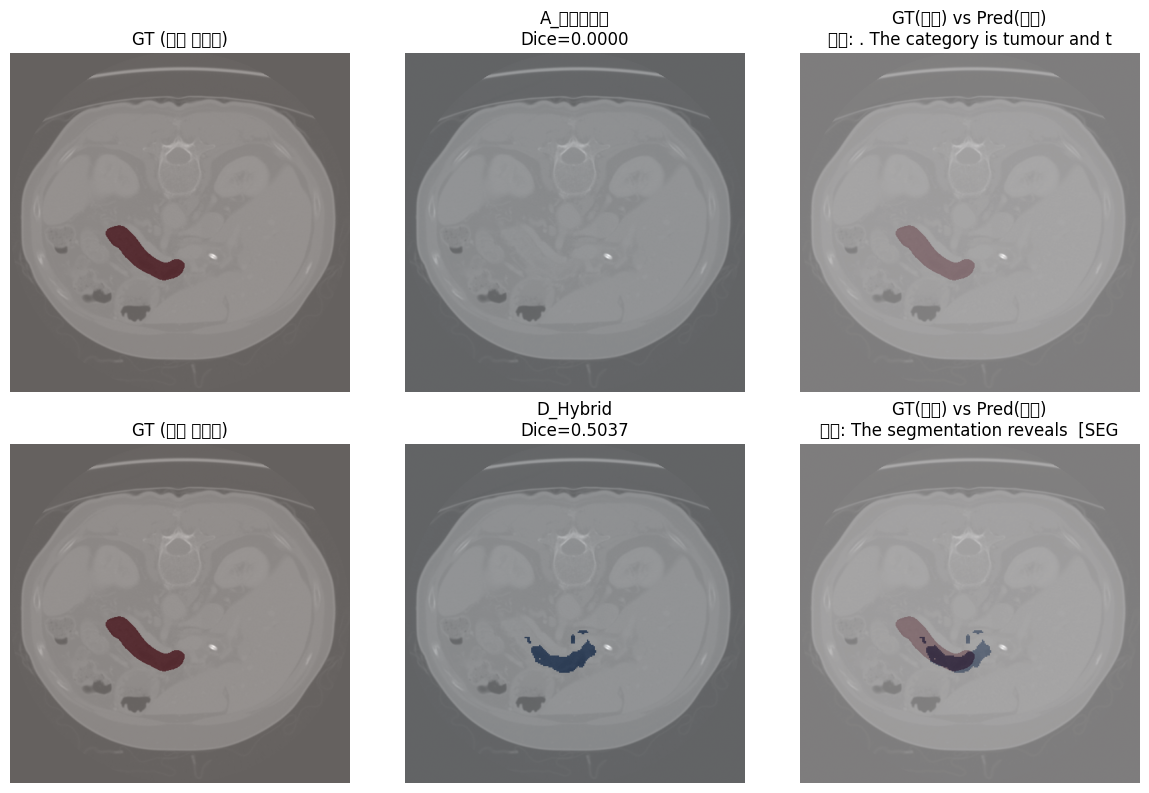

In [21]:
arr, gt_pancreas = load_case('pancreas_001')
preprocessed, _ = pipeline._prepare_image_pt(arr)

test_prompts = {
    "A_한국어직접": method_A(question_ko),
    "D_Hybrid":     method_D(question_ko),
}

fig, axes = plt.subplots(len(test_prompts), 3, figsize=(12, 4 * len(test_prompts)))
mid_slice = arr.shape[0] // 2

for row, (name, prompt) in enumerate(test_prompts.items()):
    try:
        mask, text = run_inference(preprocessed, prompt)
        mask_full = pipeline._resize_mask(mask, arr.shape)
        dice = dice_score(mask_full, gt_pancreas)

        axes[row, 0].imshow(arr[mid_slice], cmap='gray')
        axes[row, 0].imshow(gt_pancreas[mid_slice], alpha=0.4, cmap='Reds')
        axes[row, 0].set_title('GT (정답 마스크)')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(arr[mid_slice], cmap='gray')
        axes[row, 1].imshow(mask_full[mid_slice], alpha=0.4, cmap='Blues')
        axes[row, 1].set_title(f'{name}\nDice={dice:.4f}')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(arr[mid_slice], cmap='gray')
        axes[row, 2].imshow(gt_pancreas[mid_slice], alpha=0.3, cmap='Reds')
        axes[row, 2].imshow(mask_full[mid_slice], alpha=0.3, cmap='Blues')
        axes[row, 2].set_title(f'GT(빨강) vs Pred(파랑)\n응답: {text[:30]}')
        axes[row, 2].axis('off')
    except Exception as e:
        print(f"{name} 실패: {e}")

plt.tight_layout()
plt.savefig('failure_cases.png', dpi=150)
plt.show()

최종 결과

/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1126/974798337.py:37: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


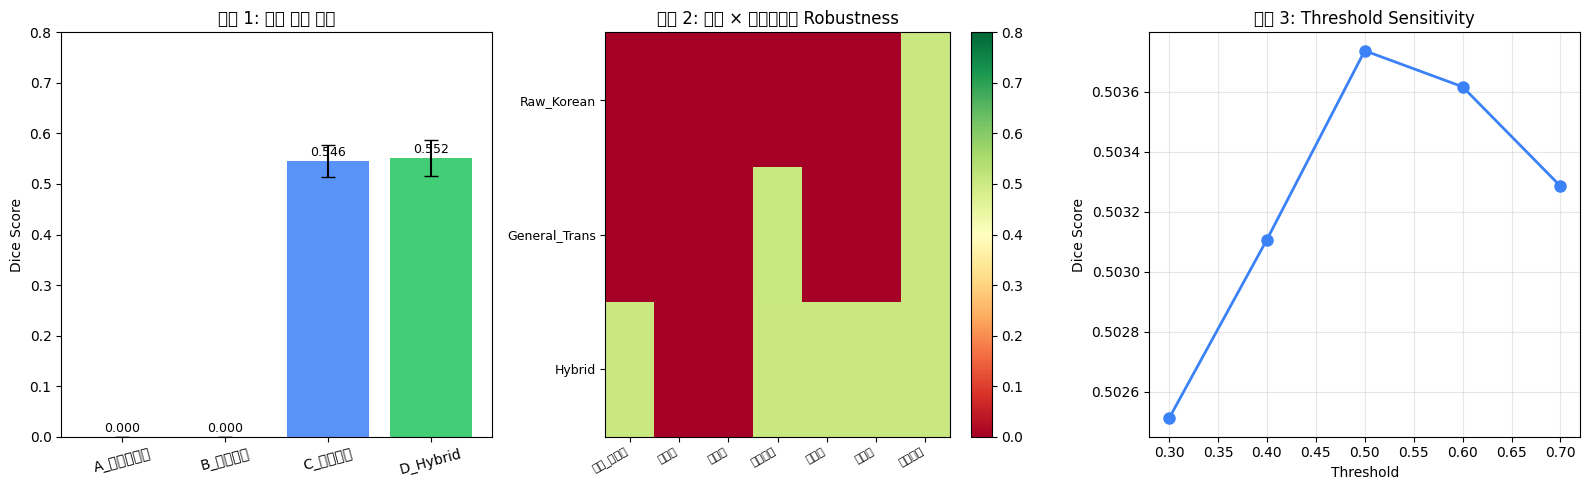

In [22]:
# 전체 결과 시각화

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 실험 1: 번역 전략 비교
names1  = list(exp1_results.keys())
means1  = [np.mean(v) for v in exp1_results.values()]
stds1   = [np.std(v)  for v in exp1_results.values()]
colors1 = ['#ef4444', '#f97316', '#3b82f6', '#22c55e']
bars = axes[0].bar(names1, means1, yerr=stds1, capsize=5, color=colors1, alpha=0.85)
axes[0].set_title('실험 1: 번역 전략 비교')
axes[0].set_ylabel('Dice Score')
axes[0].set_ylim(0, 0.8)
axes[0].tick_params(axis='x', rotation=15)
for bar, m in zip(bars, means1):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + 0.01,
                 f'{m:.3f}', ha='center', fontsize=9)

# 실험 2: Robustness 히트맵
df2 = pd.DataFrame(exp2_results).T
im = axes[1].imshow(df2.values, cmap='RdYlGn', vmin=0, vmax=0.8, aspect='auto')
axes[1].set_xticks(range(len(df2.columns)))
axes[1].set_xticklabels(df2.columns, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(df2.index)))
axes[1].set_yticklabels(df2.index, fontsize=9)
axes[1].set_title('실험 2: 표현 × 파이프라인 Robustness')
plt.colorbar(im, ax=axes[1])

# 실험 3: Threshold Sensitivity
axes[2].plot(list(th_results.keys()), list(th_results.values()),
             'o-', color='#3b82f6', linewidth=2, markersize=8)
axes[2].set_title('실험 3: Threshold Sensitivity')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Dice Score')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exp_all_results.png', dpi=150)
plt.show()

In [23]:
# 셀 15: 최종 결과 테이블

print("=" * 60)
print("실험 1: 번역 전략 비교 (n=5 cases, 췌장)")
print("=" * 60)
df1 = pd.DataFrame({
    "방법":    list(exp1_results.keys()),
    "평균Dice": [f"{np.mean(v):.4f}" for v in exp1_results.values()],
    "표준편차": [f"{np.std(v):.4f}"  for v in exp1_results.values()],
    "최대":    [f"{np.max(v):.4f}"  for v in exp1_results.values()],
    "최소":    [f"{np.min(v):.4f}"  for v in exp1_results.values()],
})
print(df1.to_string(index=False))

print("\n" + "=" * 60)
print("실험 3: Threshold Sensitivity (Hybrid, pancreas_001)")
print("=" * 60)
for th, dice in th_results.items():
    print(f"  threshold={th}: Dice={dice:.4f}")

print("\n" + "=" * 60)
print("실험 4: Tokenizer Fragmentation")
print("=" * 60)
print(df_tokens[['한국어', '영어', 'KO_count', 'EN_count']].to_string(index=False))

실험 1: 번역 전략 비교 (n=5 cases, 췌장)
      방법 평균Dice   표준편차     최대     최소
 A_한국어직접 0.0000 0.0000 0.0000 0.0000
  B_일반번역 0.0000 0.0000 0.0000 0.0000
  C_의료사전 0.5457 0.0314 0.5981 0.5109
D_Hybrid 0.5515 0.0352 0.6109 0.5037

실험 3: Threshold Sensitivity (Hybrid, pancreas_001)
  threshold=0.3: Dice=0.5025
  threshold=0.4: Dice=0.5031
  threshold=0.5: Dice=0.5037
  threshold=0.6: Dice=0.5036
  threshold=0.7: Dice=0.5033

실험 4: Tokenizer Fragmentation
한국어       영어  KO_count  EN_count
  간    liver         4         2
 신장   kidney         3         2
 췌장 pancreas         5         3
 비장   spleen         3         3
 이자 pancreas         3         3
 콩팥   kidney         7         2
대동맥    aorta         6         3
